# Sit-to-Stand Multi-Sensor Visualizer

Visualization-only notebook for `right`, `left`, `trunk`, and `sacrum` synchronized CSV folders such as `Data_Sensors/XSENS_synchronized/SRS15/Visit1/STS03`. It reuses the transition feature and plotting logic and does not modify `extract_features.py`.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "imu_features").exists():
    REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from imu_features.config import PipelineConfig
from imu_features.transition_features import extract_transition_features, transition_flexion_extension_peaks
from imu_features.utils import preprocess_activity_dataframe, select_motion_acc_signal, truncate_activity_dataframe
from validation_plots import shared_validation as sv

CONFIG = PipelineConfig(dataset_root="Data_Sensors")
ACTIVITY_NAME = "sit_to_stand"
FEATURE_PREFIX = "sit_to_stand"
sv.configure(CONFIG, sv.plot_params_from_config(CONFIG))

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


def visible_sensor_items(sensor_data):
    return [(sensor, item) for sensor, item in sensor_data.items() if item is not None and SHOW_SENSOR.get(sensor, True)]

print("Setup complete")


Setup complete


In [2]:
LAST_SENSOR_DIR_PATH = REPO_ROOT / ".data_sensors_sts_last_dir"
DEFAULT_SENSOR_ROOT = REPO_ROOT / "Data_Sensors" / "XSENS_synchronized" / "SRS15" / "Visit1" / "STS03"

# Default is False so rerunning the notebook does not create a Tkinter window.
# Set True only when you intentionally want to choose a new folder.
USE_TKINTER_FOLDER_DIALOG = True

# Optional: paste a folder path here to avoid Tkinter completely.
MANUAL_STS_FOLDER = ""


def _last_sensor_dir(default_dir=DEFAULT_SENSOR_ROOT):
    try:
        if LAST_SENSOR_DIR_PATH.exists():
            cached = Path(LAST_SENSOR_DIR_PATH.read_text().strip()).expanduser()
            if cached.exists():
                return cached
    except OSError:
        pass
    return Path(default_dir)


def _remember_sensor_dir(selected_dir):
    try:
        LAST_SENSOR_DIR_PATH.write_text(str(Path(selected_dir).resolve()))
    except OSError:
        pass


def choose_sts_folder(initial_dir=None):
    import tkinter as tk
    from tkinter import filedialog

    start_dir = _last_sensor_dir(initial_dir or DEFAULT_SENSOR_ROOT)
    root = None
    selected = ""
    try:
        root = tk.Tk()
        root.title("Choose Sit-to-Stand Folder")
        root.resizable(False, False)
        root.attributes("-topmost", True)

        width, height = 280, 90
        root.update_idletasks()
        screen_w = root.winfo_screenwidth()
        screen_h = root.winfo_screenheight()
        x = max(0, int((screen_w - width) / 2))
        y = max(0, int((screen_h - height) / 2))
        root.geometry(f"{width}x{height}+{x}+{y}")

        tk.Label(root, text="Opening folder picker...", padx=20, pady=20).pack(expand=True, fill="both")
        root.lift()
        root.focus_force()
        root.update()

        selected = filedialog.askdirectory(
            parent=root,
            title="Choose an STS folder containing right/left/trunk/sacrum",
            initialdir=str(start_dir),
        )
    finally:
        if root is not None:
            try:
                root.withdraw()
                root.update_idletasks()
                root.update()
                root.quit()
                root.destroy()
            except tk.TclError:
                pass
            root = None

    if selected:
        selected = Path(selected).resolve()
        _remember_sensor_dir(selected)
        return selected
    return None


manual = str(MANUAL_STS_FOLDER).strip()
if manual:
    STS_FOLDER = Path(manual).expanduser().resolve()
    _remember_sensor_dir(STS_FOLDER)
elif USE_TKINTER_FOLDER_DIALOG:
    STS_FOLDER = choose_sts_folder()
else:
    STS_FOLDER = _last_sensor_dir(DEFAULT_SENSOR_ROOT)

print("Selected folder:", STS_FOLDER)
print("Tkinter opens only when USE_TKINTER_FOLDER_DIALOG=True.")


Selected folder: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS17/Visit1/STS03
Tkinter opens only when USE_TKINTER_FOLDER_DIALOG=True.


In [3]:
SENSOR_ORDER = ["right", "left", "trunk", "sacrum"]
SHOW_RIGHT = True
SHOW_LEFT = True
SHOW_TRUNK = True
SHOW_SACRUM = True
SHOW_SENSOR = {
    "right": SHOW_RIGHT,
    "left": SHOW_LEFT,
    "trunk": SHOW_TRUNK,
    "sacrum": SHOW_SACRUM,
}

# STS03 has multiple CSVs per sensor in some folders. Use 0 for the first file, 1 for the second.
SENSOR_FILE_INDEX = 0


REQUESTED_FEATURE_SUFFIXES = [
    "duration",
    "time_to_peak_acc",
    "peak_acc",
    "flexion_peak",
    "extension_peak",
    "peak_gyro",
    "acc_rms",
]


def find_sensor_csv(sts_folder, sensor_name, file_index=SENSOR_FILE_INDEX):
    sts_folder = Path(sts_folder)
    direct_dir = sts_folder / sensor_name
    csvs = []
    if direct_dir.exists():
        csvs = sorted(direct_dir.glob("*synchronized*.csv")) or sorted(direct_dir.glob("*.csv"))
    if not csvs:
        matches = []
        for path in sts_folder.rglob("*.csv"):
            if sensor_name.lower() in [part.lower() for part in path.parts]:
                sync_rank = 0 if "synchronized" in path.name.lower() else 1
                matches.append((sync_rank, len(path.parts), path.name.lower(), path))
        csvs = [row[-1] for row in sorted(matches)]
    if not csvs:
        return None
    idx = int(np.clip(file_index, 0, len(csvs) - 1))
    return csvs[idx]


def transition_peak_acc_details(df, flex_ext):
    acc, acc_source = select_motion_acc_signal(df, CONFIG.prefer_useracc_for_motion)
    time_s = df["time_s"].to_numpy(dtype=float)
    mask = np.asarray(flex_ext.get("transition_mask", []), dtype=bool)
    if len(mask) != len(df) or not np.any(mask):
        mask = np.isfinite(acc) & np.isfinite(time_s)
    acc_win = np.asarray(acc, dtype=float)[mask]
    time_win = time_s[mask]
    if len(acc_win) == 0 or not np.isfinite(acc_win).any():
        return acc, acc_source, np.nan, np.nan
    peak_idx = int(np.nanargmax(acc_win))
    return acc, acc_source, float(time_win[peak_idx]), float(acc_win[peak_idx])


def load_sensor_recording(sts_folder, sensor_name):
    csv_path = find_sensor_csv(sts_folder, sensor_name)
    if csv_path is None:
        return None
    raw = pd.read_csv(csv_path)
    df_full, meta_full = preprocess_activity_dataframe(raw, CONFIG)
    df = df_full
    meta = meta_full
    flex_ext = transition_flexion_extension_peaks(
        df,
        meta,
        CONFIG,
        truncate=False,
        peak_anchor_window=True,
    )
    features = extract_transition_features(
        df,
        meta,
        CONFIG,
        FEATURE_PREFIX,
        truncate=False,
        peak_anchor_window=True,
    )
    acc, acc_source, peak_acc_time_s, peak_acc_value = transition_peak_acc_details(df, flex_ext)
    full_acc, full_acc_source = select_motion_acc_signal(df_full, CONFIG.prefer_useracc_for_motion)
    return {
        "sensor": sensor_name,
        "path": csv_path,
        "df_full": df_full,
        "meta_full": meta_full,
        "time_full_s": df_full["time_s"].to_numpy(dtype=float),
        "acc_full": np.asarray(full_acc, dtype=float),
        "acc_full_source": full_acc_source,
        "df": df,
        "meta": meta,
        "time_s": df["time_s"].to_numpy(dtype=float),
        "acc": np.asarray(acc, dtype=float),
        "acc_source": acc_source,
        "flex_ext": flex_ext,
        "features": features,
        "peak_acc_time_s": peak_acc_time_s,
        "peak_acc_value": peak_acc_value,
    }


def load_all_sensors(sts_folder):
    return {sensor: load_sensor_recording(sts_folder, sensor) for sensor in SENSOR_ORDER}


if STS_FOLDER is None:
    SENSOR_DATA = {}
    print("No folder selected")
else:
    SENSOR_DATA = load_all_sensors(STS_FOLDER)
    for sensor, item in SENSOR_DATA.items():
        if item is None:
            print(f"[missing] {sensor}")
        else:
            meta = item["meta"]
            print(f"[loaded] {sensor}: {item['path']} | n={len(item['df'])} | full_duration={meta.duration_s:.2f}s | detected_transition={item['flex_ext'].get('duration_s', np.nan):.2f}s | axis={item['flex_ext'].get('gyro_axis')}")


[loaded] right: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS17/Visit1/STS03/right/MT_012005F9_000_00B42760_synchronized.csv | n=2000 | full_duration=59.97s | detected_transition=2.25s | axis=gyro_z
[loaded] left: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS17/Visit1/STS03/left/MT_012005F9_000_00B426CC_synchronized.csv | n=2000 | full_duration=59.97s | detected_transition=3.12s | axis=gyro_z
[loaded] trunk: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS17/Visit1/STS03/trunk/MT_012005F9_000_00B4276D_synchronized.csv | n=2000 | full_duration=59.97s | detected_transition=5.55s | axis=gyro_x
[loaded] sacrum: /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/Data_Sensors/XSENS_synchronized/SRS17/Visit1/STS03/sacrum/MT_012005F9_000_00B42660_synchronized.csv | n=1999 | full_duration=59.97s | detected_transition=4.74s | axis=gyro_x


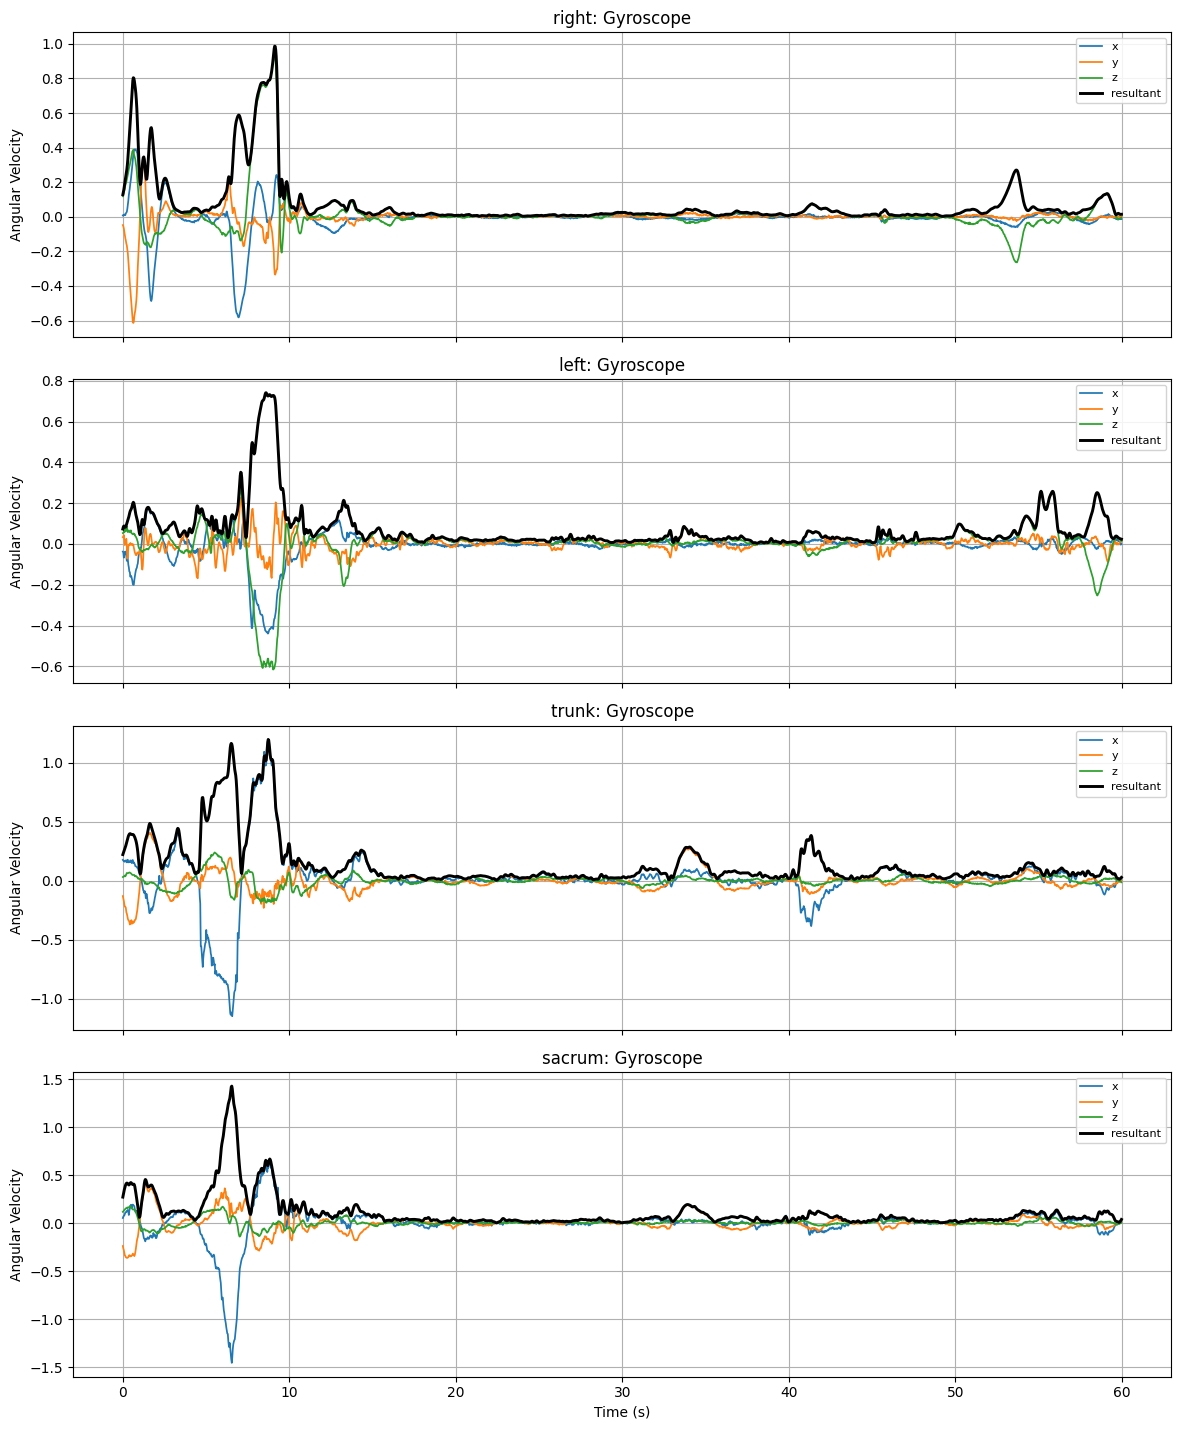

In [4]:
SHOW_GYRO_X = True
SHOW_GYRO_Y = True
SHOW_GYRO_Z = True
SHOW_GYRO_RESULTANT = True


def plot_sensor_gyroscope(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    gyro_components = [
        ("gyro_x", SHOW_GYRO_X, "x"),
        ("gyro_y", SHOW_GYRO_Y, "y"),
        ("gyro_z", SHOW_GYRO_Z, "z"),
        ("gyro_mag", SHOW_GYRO_RESULTANT, "resultant"),
    ]
    active_components = [(col, label) for col, show, label in gyro_components if show]
    if not active_components:
        print("No gyroscope components selected")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.6 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        df = item.get("df_full", item["df"])
        t = item.get("time_full_s", item["time_s"])
        for col, label in active_components:
            if col in df:
                linewidth = 2.1 if label == "resultant" else 1.25
                color = "black" if label == "resultant" else None
                ax.plot(t, df[col].to_numpy(dtype=float), linewidth=linewidth, color=color, label=label)
        ax.set_title(f"{sensor}: Gyroscope")
        ax.set_ylabel("Angular Velocity")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


plot_sensor_gyroscope(SENSOR_DATA)


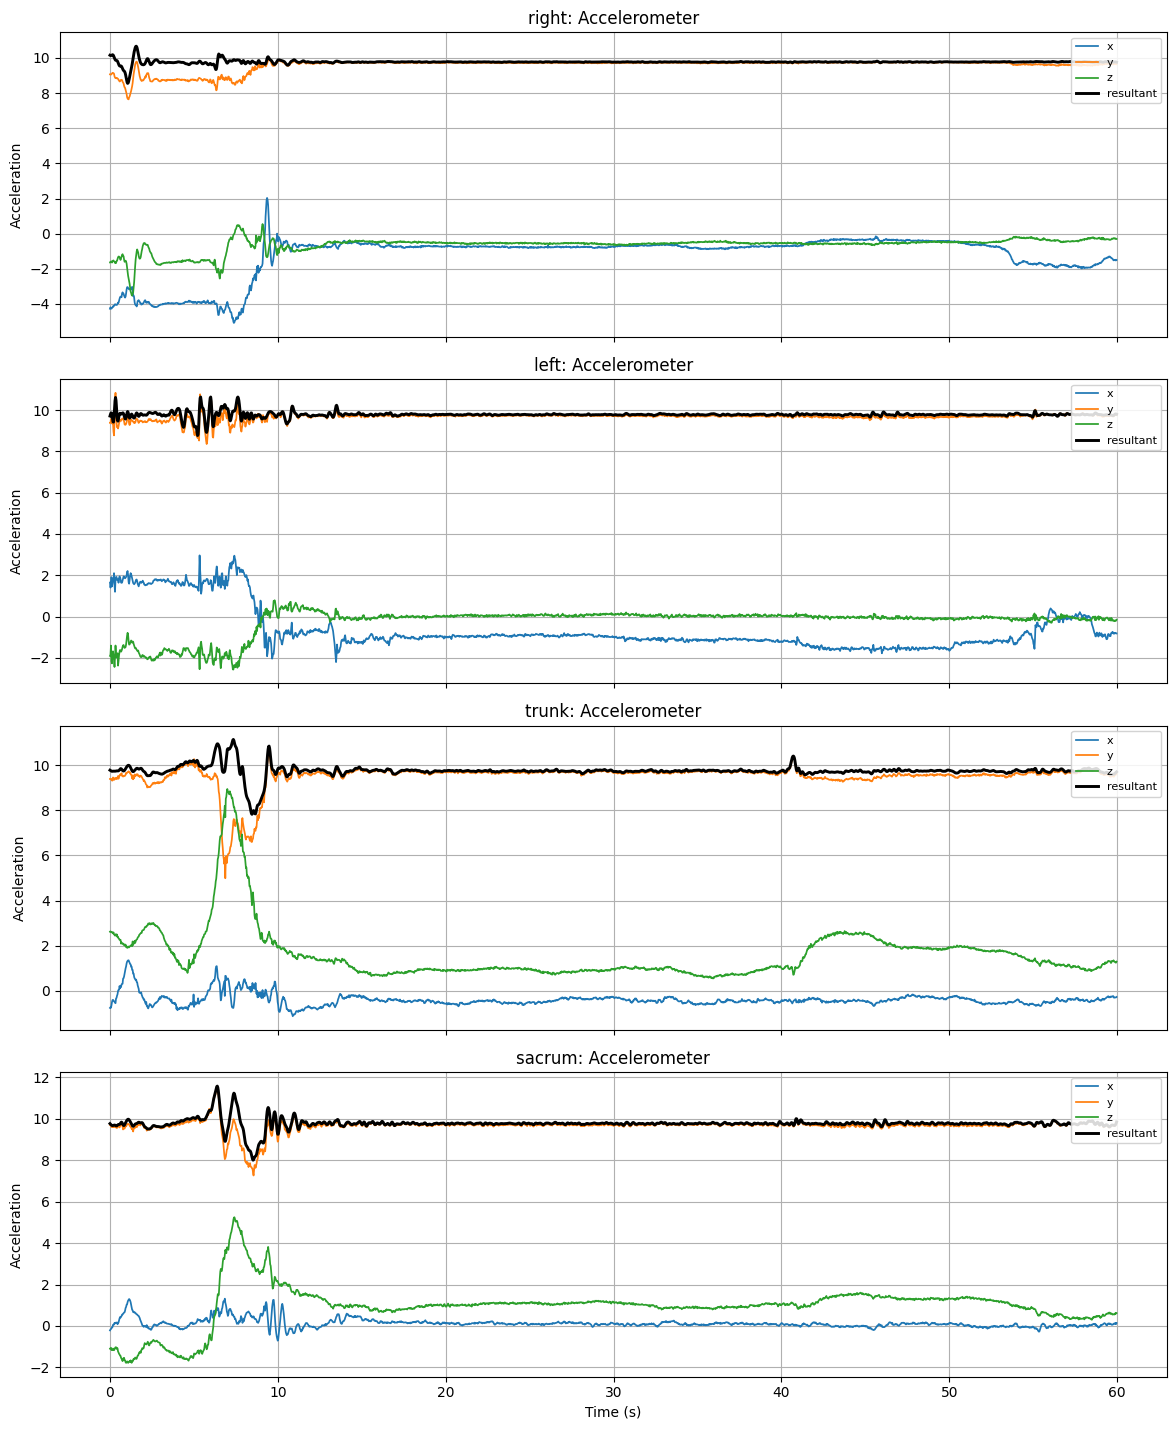

In [5]:
SHOW_ACCEL_X = True
SHOW_ACCEL_Y = True
SHOW_ACCEL_Z = True
SHOW_ACCEL_RESULTANT = True


def plot_sensor_accelerometer(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    accel_components = [
        ("accel_x", SHOW_ACCEL_X, "x"),
        ("accel_y", SHOW_ACCEL_Y, "y"),
        ("accel_z", SHOW_ACCEL_Z, "z"),
        ("acc_mag", SHOW_ACCEL_RESULTANT, "resultant"),
    ]
    active_components = [(col, label) for col, show, label in accel_components if show]
    if not active_components:
        print("No accelerometer components selected")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.6 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        df = item.get("df_full", item["df"])
        t = item.get("time_full_s", item["time_s"])
        for col, label in active_components:
            if col in df:
                linewidth = 2.1 if label == "resultant" else 1.25
                color = "black" if label == "resultant" else None
                ax.plot(t, df[col].to_numpy(dtype=float), linewidth=linewidth, color=color, label=label)
        ax.set_title(f"{sensor}: Accelerometer")
        ax.set_ylabel("Acceleration")
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


plot_sensor_accelerometer(SENSOR_DATA)


In [6]:
def sensor_summary_row(sensor, item):
    flex_ext = item["flex_ext"]
    features = item["features"]
    row = {
        "sensor": sensor,
        "file": item["path"].name,
        "acc_source": item["acc_source"],
        "gyro_axis": flex_ext.get("gyro_axis"),
        "fs_hz": item["meta"].fs_hz,
        "full_duration_s": item["meta_full"].duration_s,
        "start_time_s": flex_ext.get("start_time_s", np.nan),
        "end_time_s": flex_ext.get("end_time_s", np.nan),
    }
    for suffix in REQUESTED_FEATURE_SUFFIXES:
        row[suffix] = features.get(f"{FEATURE_PREFIX}_{suffix}", np.nan)
    return row


summary_table = pd.DataFrame(
    [sensor_summary_row(sensor, item) for sensor, item in SENSOR_DATA.items() if item is not None]
)
if len(summary_table):
    display(summary_table.round(3))
else:
    print("No sensor data loaded")


,sensor,file,acc_source,gyro_axis,fs_hz,full_duration_s,start_time_s,end_time_s,duration,time_to_peak_acc,peak_acc,flexion_peak,extension_peak,peak_gyro,acc_rms
0,right,MT_012005F9_000_00B42760_synchronized.csv,acc_mag_gravity_removed,gyro_z,33.333,59.97,7.410,9.660,2.250,2.010,0.301,0.924,-0.207,0.987,0.100
1,left,MT_012005F9_000_00B426CC_synchronized.csv,acc_mag_gravity_removed,gyro_z,33.333,59.97,6.570,9.690,3.120,1.050,0.851,0.278,-0.616,0.741,0.266
2,trunk,MT_012005F9_000_00B4276D_synchronized.csv,acc_mag_gravity_removed,gyro_x,33.333,59.97,4.590,10.140,5.550,2.760,1.390,1.186,-1.150,1.199,0.869
3,sacrum,MT_012005F9_000_00B42660_synchronized.csv,acc_mag_gravity_removed,gyro_x,33.317,59.97,4.622,9.365,4.742,1.771,1.806,0.652,-1.457,1.428,0.891


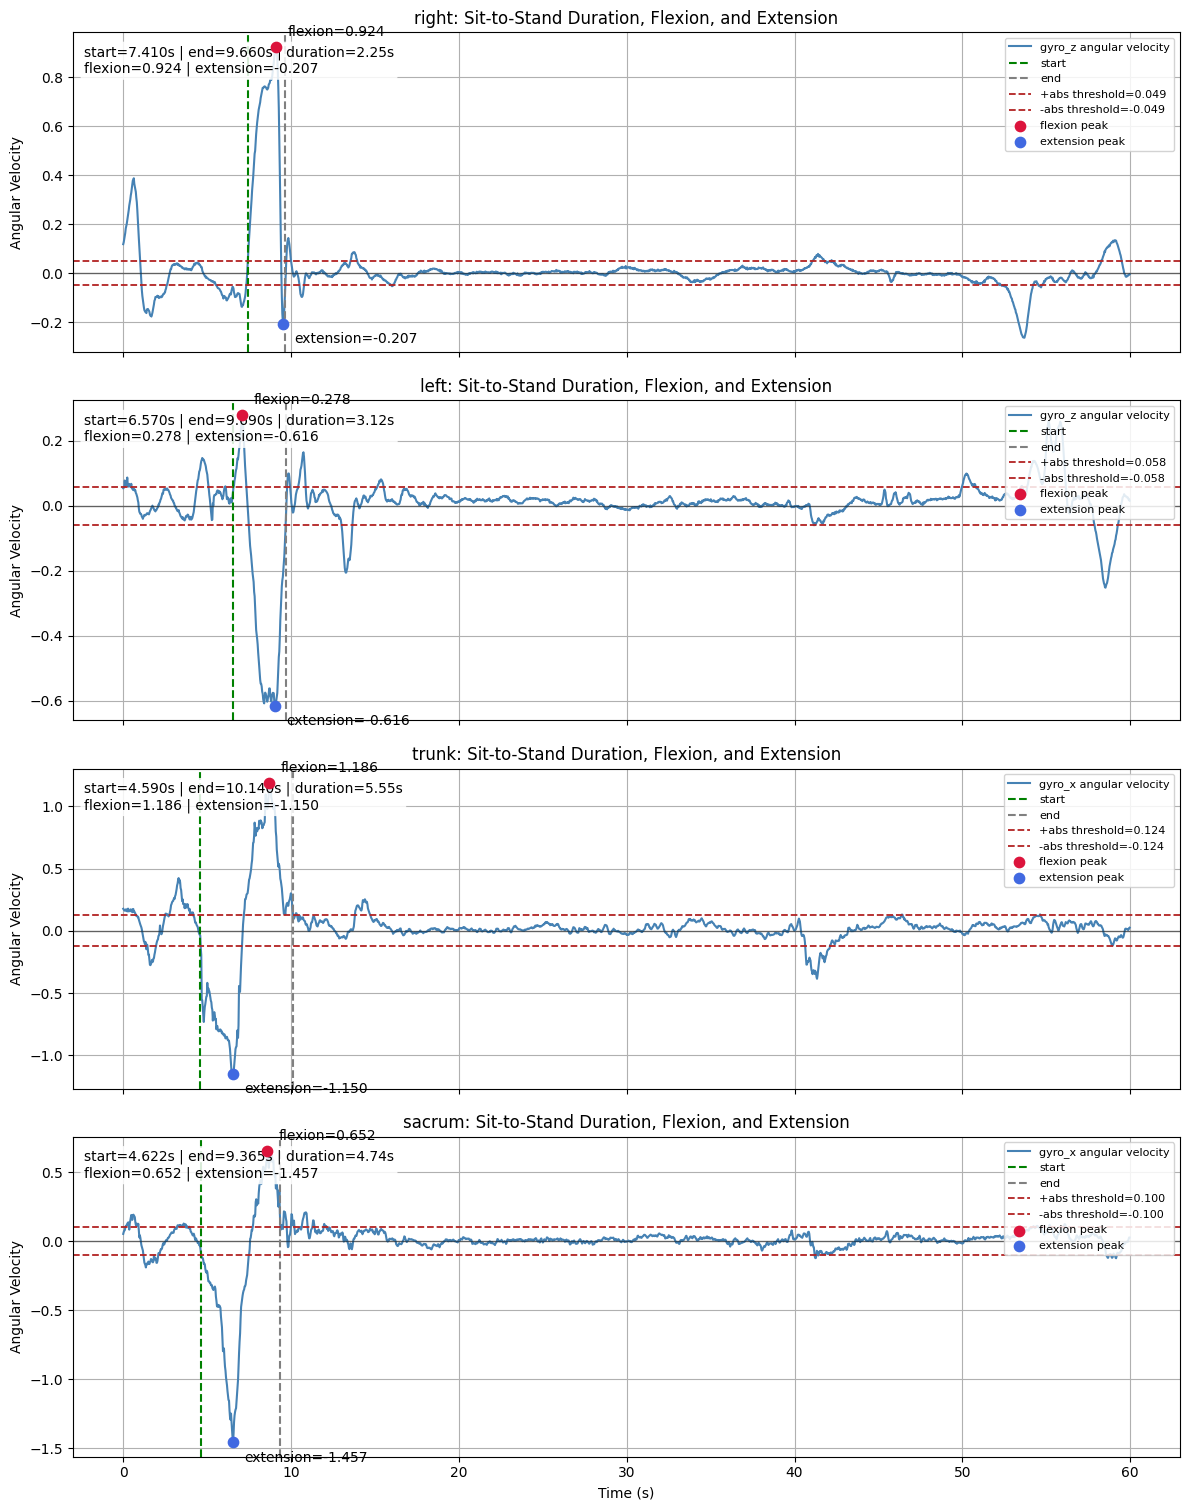

In [7]:
def plot_transition_gyro(sensor_data):
    items = visible_sensor_items(sensor_data)
    if not items:
        print("No visible sensors. Set one of SHOW_RIGHT/SHOW_LEFT/SHOW_TRUNK/SHOW_SACRUM to True and rerun.")
        return

    fig, axes = plt.subplots(len(items), 1, figsize=(12, 3.8 * len(items)), sharex=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (sensor, item) in zip(axes, items):
        flex_ext = item["flex_ext"]
        axis = flex_ext.get("gyro_axis") or "gyro_mag"
        df_plot = item.get("df_full", item["df"])
        t = item.get("time_full_s", item["time_s"])
        if axis in df_plot:
            gyro = df_plot[axis].to_numpy(dtype=float)
        else:
            gyro = df_plot["gyro_mag"].to_numpy(dtype=float)
        start_t = flex_ext.get("start_time_s", np.nan)
        end_t = flex_ext.get("end_time_s", np.nan)
        duration = flex_ext.get("duration_s", np.nan)
        threshold = flex_ext.get("threshold", np.nan)

        ax.plot(t, gyro, color="steelblue", linewidth=1.5, label=f"{axis} angular velocity")
        ax.axhline(0, color="black", linewidth=1.0, alpha=0.45)
        if np.isfinite(start_t):
            ax.axvline(start_t, color="green", linestyle="--", linewidth=1.5, label="start")
        if np.isfinite(end_t):
            ax.axvline(end_t, color="gray", linestyle="--", linewidth=1.5, label="end")
        if np.isfinite(threshold):
            ax.axhline(threshold, color="firebrick", linestyle="--", linewidth=1.3, label=f"+abs threshold={threshold:.3f}")
            ax.axhline(-threshold, color="firebrick", linestyle="--", linewidth=1.3, label=f"-abs threshold={-threshold:.3f}")

        flexion = flex_ext.get("flexion_peak", np.nan)
        flexion_t = flex_ext.get("flexion_peak_time_s", np.nan)
        extension = flex_ext.get("extension_peak", np.nan)
        extension_t = flex_ext.get("extension_peak_time_s", np.nan)
        if np.isfinite(flexion) and np.isfinite(flexion_t):
            ax.scatter(flexion_t, flexion, color="crimson", s=55, zorder=6, label="flexion peak")
            ax.annotate(f"flexion={flexion:.3f}", (flexion_t, flexion), textcoords="offset points", xytext=(8, 8))
        if np.isfinite(extension) and np.isfinite(extension_t):
            ax.scatter(extension_t, extension, color="royalblue", s=55, zorder=6, label="extension peak")
            ax.annotate(f"extension={extension:.3f}", (extension_t, extension), textcoords="offset points", xytext=(8, -14))

        ax.set_title(f"{sensor}: Sit-to-Stand Duration, Flexion, and Extension")
        ax.set_ylabel("Angular Velocity")
        ax.text(
            0.01,
            0.96,
            f"start={start_t:.3f}s | end={end_t:.3f}s | duration={duration:.2f}s\nflexion={flexion:.3f} | extension={extension:.3f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.25"),
        )
        ax.legend(loc="upper right", fontsize=8, framealpha=0.85)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


plot_transition_gyro(SENSOR_DATA)
